In [3]:
"""
Task 0 helper for the Applied Trading Strategies backtesting project.

Purpose
-------
1. Read the commodities workbook.
2. Clean the commodity return-index table and align it with the Assets sheet.
3. Convert excess return indices into daily simple returns.
4. Build an equally weighted commodity market factor to use as the benchmark.
5. Save clean outputs for later strategy/model backtests.

Input workbook expected:
    Commodities Data thru 15May25.xlsx
with sheets:
    - Return Indices
    - Assets

The factor is calculated from daily returns, not from index levels directly.
Missing commodity returns are not filled with zero. The script outputs two factor
versions:
    - MKT_EQ_WEIGHT_AVAILABLE: average of commodities with available return on that date
    - MKT_EQ_WEIGHT_FULL_UNIVERSE: average only when all 23 commodities have returns

For later model benchmarking, use one consistently across the report. The default
benchmark returned by `build_task0_dataset` is MKT_EQ_WEIGHT_AVAILABLE because it
keeps the maximum history while making the active universe count explicit.
"""

from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from typing import Dict, Iterable, Tuple

import numpy as np
import pandas as pd


# -----------------------------------------------------------------------------
# User-editable settings
# -----------------------------------------------------------------------------
COMMODITIES_FILE = Path("Commodities Data thru 15May25.xlsx")
RETURN_INDICES_SHEET = "Return Indices"
ASSETS_SHEET = "Assets"
DATE_COL = "Dates"
TRAIN_END = pd.Timestamp("2019-12-31")
TEST_START = pd.Timestamp("2020-01-01")
TRADING_DAYS_PER_YEAR = 252


@dataclass
class Task0Data:
    """Container returned by the Task 0 data-building function."""

    index_levels: pd.DataFrame
    returns: pd.DataFrame
    assets: pd.DataFrame
    market_factor: pd.DataFrame
    summary_stats: pd.DataFrame
    corr_matrix: pd.DataFrame


# -----------------------------------------------------------------------------
# Cleaning helpers
# -----------------------------------------------------------------------------
def _normalise_text(x: object) -> str:
    """Standardise strings for reliable matching between workbook sheets."""
    return " ".join(str(x).strip().upper().split())


def _match_return_columns_to_assets(
    return_columns: Iterable[str], asset_names: Iterable[str]
) -> Dict[str, str]:
    """
    Match verbose Bloomberg-style return-index column names to clean asset names.

    Example:
        'BRENT CRUDE FUTR  Jul25' -> 'BRENT CRUDE'
        'WHEAT FUTURE(CBT) Jul25' -> 'WHEAT FUTURE'

    The matching uses the longest asset-name prefix first, which avoids accidental
    short matches when one name is nested inside another.
    """
    asset_names = [str(a).strip() for a in asset_names]
    asset_names_sorted = sorted(asset_names, key=lambda s: len(_normalise_text(s)), reverse=True)

    mapping: Dict[str, str] = {}
    unmatched = []

    for raw_col in return_columns:
        raw_norm = _normalise_text(raw_col)
        match = None

        for asset in asset_names_sorted:
            asset_norm = _normalise_text(asset)
            if raw_norm.startswith(asset_norm):
                match = asset
                break

        if match is None:
            unmatched.append(raw_col)
        else:
            mapping[raw_col] = match

    if unmatched:
        raise ValueError(
            "Could not match these return-index columns to the Assets sheet: "
            + ", ".join(map(str, unmatched))
        )

    clean_names = list(mapping.values())
    if len(clean_names) != len(set(clean_names)):
        duplicates = pd.Series(clean_names).value_counts()
        duplicates = duplicates[duplicates > 1].index.tolist()
        raise ValueError(f"Duplicate asset-name mapping detected: {duplicates}")

    return mapping


def load_commodities_workbook(
    file_path: Path | str = COMMODITIES_FILE,
    return_sheet: str = RETURN_INDICES_SHEET,
    assets_sheet: str = ASSETS_SHEET,
    date_col: str = DATE_COL,
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """Load and clean the commodities return-index levels and asset sector map."""
    file_path = Path(file_path)
    if not file_path.exists():
        raise FileNotFoundError(
            f"Cannot find {file_path}. Put the Excel file in the same folder as this script "
            "or pass an absolute path to build_task0_dataset(...)."
        )

    raw_indices = pd.read_excel(file_path, sheet_name=return_sheet)
    assets = pd.read_excel(file_path, sheet_name=assets_sheet)

    required_asset_cols = {"Commodity", "Sector"}
    missing_asset_cols = required_asset_cols - set(assets.columns)
    if missing_asset_cols:
        raise ValueError(f"Assets sheet is missing columns: {sorted(missing_asset_cols)}")

    if date_col not in raw_indices.columns:
        raise ValueError(f"Return Indices sheet must contain a '{date_col}' column.")

    # Clean asset metadata.
    assets = assets.copy()
    assets["Commodity"] = assets["Commodity"].astype(str).str.strip()
    assets["Sector"] = assets["Sector"].astype(str).str.strip()

    # Clean dates and sort.
    raw_indices = raw_indices.copy()
    raw_indices[date_col] = pd.to_datetime(raw_indices[date_col])
    raw_indices = raw_indices.dropna(subset=[date_col]).sort_values(date_col)
    raw_indices = raw_indices.drop_duplicates(subset=[date_col], keep="last")
    raw_indices = raw_indices.set_index(date_col)

    # Convert data columns to numeric, preserving NaNs.
    raw_indices = raw_indices.apply(pd.to_numeric, errors="coerce")

    # Rename verbose columns to clean commodity names using Assets sheet.
    col_map = _match_return_columns_to_assets(raw_indices.columns, assets["Commodity"])
    index_levels = raw_indices.rename(columns=col_map)

    # Reorder columns to follow the Assets sheet order.
    ordered_assets = assets["Commodity"].tolist()
    index_levels = index_levels[ordered_assets]

    return index_levels, assets


# -----------------------------------------------------------------------------
# Core calculations
# -----------------------------------------------------------------------------
def compute_daily_returns(index_levels: pd.DataFrame) -> pd.DataFrame:
    """
    Convert excess return indices into daily simple returns.

    Important: fill_method=None prevents pandas from forward-filling missing index
    levels before calculating returns. This avoids accidentally creating artificial
    zero returns when an asset has not started trading in the dataset.
    """
    returns = index_levels.pct_change(fill_method=None)
    returns = returns.replace([np.inf, -np.inf], np.nan)
    return returns


def build_market_factor(returns: pd.DataFrame) -> pd.DataFrame:
    """
    Construct the equally weighted commodity market factor.

    MKT_EQ_WEIGHT_AVAILABLE averages across non-missing commodity returns on each
    date. MKT_EQ_WEIGHT_FULL_UNIVERSE only reports a value when every commodity has
    a valid return on the same date.
    """
    n_assets = returns.shape[1]
    active_assets = returns.notna().sum(axis=1)

    factor_available = returns.mean(axis=1, skipna=True)
    factor_available = factor_available.where(active_assets > 0)

    factor_full = returns.where(active_assets.eq(n_assets)).mean(axis=1, skipna=True)
    factor_full = factor_full.where(active_assets.eq(n_assets))

    out = pd.DataFrame(
        {
            "MKT_EQ_WEIGHT_AVAILABLE": factor_available,
            "MKT_EQ_WEIGHT_FULL_UNIVERSE": factor_full,
            "ACTIVE_ASSETS": active_assets,
            "TOTAL_ASSETS": n_assets,
        },
        index=returns.index,
    )

    # Cumulative benchmark indices, starting at 100. These are for plotting only.
    for col in ["MKT_EQ_WEIGHT_AVAILABLE", "MKT_EQ_WEIGHT_FULL_UNIVERSE"]:
        idx_col = col.replace("MKT_EQ_WEIGHT", "MKT_INDEX")
        valid = out[col].dropna()
        index_series = pd.Series(np.nan, index=out.index, dtype=float)
        if not valid.empty:
            index_series.loc[valid.index] = 100.0 * (1.0 + valid).cumprod()
        out[idx_col] = index_series

    out["SAMPLE"] = np.where(out.index <= TRAIN_END, "Train", "Test")
    return out


def calculate_summary_stats(returns: pd.DataFrame) -> pd.DataFrame:
    """Basic Task 0 summary statistics for each commodity return series."""
    stats = pd.DataFrame(index=returns.columns)
    stats["Observations"] = returns.count()
    stats["Start"] = returns.apply(lambda s: s.dropna().index.min())
    stats["End"] = returns.apply(lambda s: s.dropna().index.max())
    stats["Daily Mean"] = returns.mean()
    stats["Daily Vol"] = returns.std()
    stats["Annualised Mean"] = returns.mean() * TRADING_DAYS_PER_YEAR
    stats["Annualised Vol"] = returns.std() * np.sqrt(TRADING_DAYS_PER_YEAR)
    stats["Annualised Sharpe"] = stats["Annualised Mean"] / stats["Annualised Vol"]
    stats["Min Daily Return"] = returns.min()
    stats["Max Daily Return"] = returns.max()
    return stats


def split_train_test(df: pd.DataFrame) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """Split any date-indexed DataFrame using the assignment guideline."""
    train = df.loc[df.index <= TRAIN_END].copy()
    test = df.loc[df.index >= TEST_START].copy()
    return train, test


def build_task0_dataset(
    commodities_file: Path | str = COMMODITIES_FILE,
) -> Task0Data:
    """Run the full Task 0 data pipeline and return clean DataFrames."""
    index_levels, assets = load_commodities_workbook(commodities_file)
    returns = compute_daily_returns(index_levels)
    market_factor = build_market_factor(returns)
    summary_stats = calculate_summary_stats(returns)
    corr_matrix = returns.corr()

    return Task0Data(
        index_levels=index_levels,
        returns=returns,
        assets=assets,
        market_factor=market_factor,
        summary_stats=summary_stats,
        corr_matrix=corr_matrix,
    )


# -----------------------------------------------------------------------------
# Save outputs
# -----------------------------------------------------------------------------
def save_task0_outputs(data: Task0Data, output_dir: Path | str = "task0_outputs") -> None:
    """Save CSV outputs that can be reused in later tasks."""
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    data.index_levels.to_csv(output_dir / "commodity_index_levels_clean.csv", index_label="Date")
    data.returns.to_csv(output_dir / "commodity_daily_returns.csv", index_label="Date")
    data.assets.to_csv(output_dir / "commodity_assets_and_sectors.csv", index=False)
    data.market_factor.to_csv(output_dir / "commodity_market_factor.csv", index_label="Date")
    data.summary_stats.to_csv(output_dir / "task0_summary_stats.csv", index_label="Commodity")
    data.corr_matrix.to_csv(output_dir / "task0_return_correlations.csv", index_label="Commodity")


def print_quick_checks(data: Task0Data) -> None:
    """Print a compact sanity check after running the script."""
    returns = data.returns
    mf = data.market_factor

    print("\nTask 0 data build complete")
    print("- Commodities:", returns.shape[1])
    print("- Return observations:", returns.shape[0])
    print("- Date range:", returns.index.min().date(), "to", returns.index.max().date())
    print("- First valid available-universe factor date:", mf["MKT_EQ_WEIGHT_AVAILABLE"].first_valid_index().date())
    full_start = mf["MKT_EQ_WEIGHT_FULL_UNIVERSE"].first_valid_index()
    print("- First valid full-universe factor date:", full_start.date() if full_start is not None else None)

    train, test = split_train_test(mf)
    print("- Train rows:", len(train), "ending", train.index.max().date())
    print("- Test rows:", len(test), "starting", test.index.min().date())

    print("\nMarket factor preview:")
    print(mf[["MKT_EQ_WEIGHT_AVAILABLE", "MKT_EQ_WEIGHT_FULL_UNIVERSE", "ACTIVE_ASSETS", "SAMPLE"]].dropna(how="all").tail(5))


if __name__ == "__main__":
    # If the workbook is in a different folder, replace COMMODITIES_FILE below
    # with an absolute path, e.g. Path(r"C:\Users\YourName\Downloads\Commodities Data thru 15May25.xlsx")
    data = build_task0_dataset(COMMODITIES_FILE)
    save_task0_outputs(data, output_dir="task0_outputs")
    print_quick_checks(data)



Task 0 data build complete
- Commodities: 23
- Return observations: 14707
- Date range: 1969-01-01 to 2025-05-15
- First valid available-universe factor date: 1969-01-02
- First valid full-universe factor date: 2005-10-05
- Train rows: 13305 ending 2019-12-31
- Test rows: 1402 starting 2020-01-01

Market factor preview:
            MKT_EQ_WEIGHT_AVAILABLE  MKT_EQ_WEIGHT_FULL_UNIVERSE  \
Dates                                                              
2025-05-09                 0.011100                     0.011100   
2025-05-12                -0.001747                    -0.001747   
2025-05-13                 0.013882                     0.013882   
2025-05-14                -0.004399                    -0.004399   
2025-05-15                -0.001904                    -0.001904   

            ACTIVE_ASSETS SAMPLE  
Dates                             
2025-05-09             23   Test  
2025-05-12             23   Test  
2025-05-13             23   Test  
2025-05-14             23

In [4]:
"""
Task 3 helper: neural-network predictive signals for selected commodities.

This code is designed to be pasted as the next code block after Task 0 in a
Jupyter notebook, but it is also runnable as a standalone Python script.

What it does
------------
1. Reads commodity excess return indices from the commodities workbook.
2. Reads auxiliary market variables from the auxiliary workbook.
3. Builds the compact auxiliary feature set requested for the neural network:
   - USD strength
   - FX volatility and commodity-FX skew
   - rates / curve conditions
   - equity / credit risk appetite
   - JPM EASI and IMM positioning
4. Fits one small neural network per commodity using only the training window.
5. Outputs predictive signals for the test window from 2020 onward.

The target is a 21-trading-day forward return divided by trailing 60-day annualised
volatility. Features are shifted by 1 trading day before being used, so the row dated
`t` uses only information observable by the end of `t-1` and predicts returns from
`t` onward. The validation window is also truncated 21 business days before the
training/test split, so validation labels do not use any return information from the
2020+ test period. These choices are deliberately conservative to reduce look-ahead risk.
"""

from __future__ import annotations

import json
import math
import random
import re
import warnings
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, Iterable, List, Tuple

import numpy as np
import pandas as pd

from sklearn.impute import SimpleImputer
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
warnings.filterwarnings("ignore", category=FutureWarning)


# =============================================================================
# User-editable settings
# =============================================================================
COMMODITIES_FILE = Path("Commodities Data thru 15May25.xlsx")
AUX_FILE = Path("DataTables Updated thru 15May25.xlsx")
OUTPUT_DIR = Path("task3_nn_outputs")

DATE_COL = "Dates"
TRAIN_END = pd.Timestamp("2019-12-31")
TEST_START = pd.Timestamp("2020-01-01")
VALIDATION_START = pd.Timestamp("2019-01-01")

TRADING_DAYS = 252
TARGET_HORIZON_DAYS = 21
# Because the target uses a forward 21-trading-day return, the validation set must
# stop 21 business days before TRAIN_END. Otherwise late-December 2019 validation
# labels would include January 2020 returns and slightly contaminate model selection.
VALIDATION_END = TRAIN_END - pd.tseries.offsets.BDay(TARGET_HORIZON_DAYS)
FEATURE_LAG_DAYS = 1
MODEL_START_DATE = pd.Timestamp("2003-11-01")
MIN_FEATURE_COVERAGE_IN_TRAIN = 0.45
TARGET_CLIP_ABS = 5.0

RANDOM_SEED = 42
BATCH_SIZE = 128  # retained for possible mini-batch extension; current model uses full-batch updates for speed
MAX_EPOCHS = 400
PATIENCE = 25
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
HIDDEN_UNITS = (32, 16)
DROPOUT = 0.15

# Focused universe requested by the user.
# Keys are report-friendly names. Values are clean commodity names from the Assets sheet.
SELECTED_COMMODITIES = {
    "Gold": "GOLD 100 OZ",
    "Silver": "SILVER",
    "Brent_Crude": "BRENT CRUDE",
    "Natural_Gas": "NATURAL GAS",
}

# Compact auxiliary feature set used as neural-network inputs.
# Keep these names unchanged because downstream outputs and feature-map files use them.
REQUIRED_AUX_FEATURES = [
    "usd_strength_ret_21d",
    "g10_fx_atm_vol_1M_chg_21d",
    "commodity_fx_rr_chg_21d",
    "us_10y_chg_21d",
    "us_curve_10y_minus_3m",
    "global_ex_us_10y_chg_21d",
    "global_equity_ret_21d",
    "spx_realised_vol_21d",
    "cdx_hy_chg_21d",
    "cdx_hy_minus_ig",
    "itraxx_xover_minus_ig_chg_21d",
    "easi_global_chg_21d",
    "imm_positioning_z_basket",
]


# =============================================================================
# Utility helpers
# =============================================================================
def set_global_seed(seed: int = RANDOM_SEED) -> None:
    """Make the neural-network training reasonably reproducible."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    # Small tabular models are faster and more reproducible with one CPU thread.
    torch.set_num_threads(1)


def normalise_text(x: object) -> str:
    """Standardise strings for reliable matching."""
    return " ".join(str(x).strip().upper().split())


def ensure_file_exists(path: Path) -> Path:
    """Support both notebook working directory and /mnt/data execution."""
    path = Path(path)
    candidates = [path, Path.cwd() / path.name, Path("/mnt/data") / path.name]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    raise FileNotFoundError(f"Could not find {path.name}. Tried: {candidates}")


def clean_sheet(df: pd.DataFrame, date_col: str = DATE_COL) -> pd.DataFrame:
    """Clean a worksheet into a date-indexed numeric DataFrame."""
    if date_col not in df.columns:
        raise ValueError(f"Expected a '{date_col}' column but found: {list(df.columns)[:5]}")
    out = df.copy()
    out[date_col] = pd.to_datetime(out[date_col], errors="coerce")
    out = out.dropna(subset=[date_col]).sort_values(date_col)
    out = out.drop_duplicates(subset=[date_col], keep="last")
    out = out.set_index(date_col)
    out = out.apply(pd.to_numeric, errors="coerce")
    out = out.replace([np.inf, -np.inf], np.nan)
    return out


def pct_change(df: pd.DataFrame, periods: int) -> pd.DataFrame:
    """Percentage change without forward-filling missing observations."""
    return df.pct_change(periods=periods, fill_method=None).replace([np.inf, -np.inf], np.nan)


def rolling_zscore(s: pd.Series, window: int = 252, min_periods: int = 126) -> pd.Series:
    """Rolling z-score using only past and current observations."""
    mean = s.rolling(window, min_periods=min_periods).mean()
    std = s.rolling(window, min_periods=min_periods).std()
    return ((s - mean) / std).replace([np.inf, -np.inf], np.nan)


def basket_mean(df: pd.DataFrame, columns: Iterable[str], min_count: int = 1) -> pd.Series:
    """Average a basket, using available members but requiring a minimum count."""
    cols = [c for c in columns if c in df.columns]
    if not cols:
        return pd.Series(index=df.index, dtype=float)
    valid_count = df[cols].notna().sum(axis=1)
    out = df[cols].mean(axis=1, skipna=True)
    out = out.where(valid_count >= min_count)
    return out


def make_col_safe(x: str) -> str:
    """Clean column names for CSV/report readability."""
    x = re.sub(r"[^A-Za-z0-9]+", "_", str(x).strip())
    x = re.sub(r"_+", "_", x).strip("_")
    return x


# =============================================================================
# Commodity data loading
# =============================================================================
def match_return_columns_to_assets(return_columns: Iterable[str], asset_names: Iterable[str]) -> Dict[str, str]:
    """Map verbose return-index columns to clean asset names from the Assets sheet."""
    asset_names = [str(a).strip() for a in asset_names]
    asset_names_sorted = sorted(asset_names, key=lambda s: len(normalise_text(s)), reverse=True)
    mapping: Dict[str, str] = {}
    unmatched = []

    for raw_col in return_columns:
        raw_norm = normalise_text(raw_col)
        match = None
        for asset in asset_names_sorted:
            if raw_norm.startswith(normalise_text(asset)):
                match = asset
                break
        if match is None:
            unmatched.append(raw_col)
        else:
            mapping[raw_col] = match

    if unmatched:
        raise ValueError("Could not match these commodity columns: " + ", ".join(unmatched))
    return mapping


def load_commodity_returns(file_path: Path = COMMODITIES_FILE) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """Load return-index levels, daily returns, and asset metadata."""
    file_path = ensure_file_exists(file_path)
    raw = pd.read_excel(file_path, sheet_name="Return Indices")
    assets = pd.read_excel(file_path, sheet_name="Assets")
    assets["Commodity"] = assets["Commodity"].astype(str).str.strip()
    assets["Sector"] = assets["Sector"].astype(str).str.strip()

    raw = clean_sheet(raw)
    col_map = match_return_columns_to_assets(raw.columns, assets["Commodity"])
    levels = raw.rename(columns=col_map)
    levels = levels[assets["Commodity"].tolist()]
    returns = pct_change(levels, 1)
    return levels, returns, assets



# =============================================================================
# Auxiliary feature engineering
# =============================================================================
def load_auxiliary_sheets(file_path: Path = AUX_FILE) -> Dict[str, pd.DataFrame]:
    """Load only the auxiliary sheets required for the compact feature set."""
    file_path = ensure_file_exists(file_path)
    sheets = [
        "FX SPOT",
        "ATM VOLS",
        "3M 25D RR",
        "3M DEPOSIT RATES",
        "10Y YIELD",
        "EQUITY INDICES",
        "CREDIT SPREADS",
        "JPM EASI",
        "IMM POSITIONING",
    ]
    aux = {}
    try:
        raw_sheets = pd.read_excel(file_path, sheet_name=sheets)
    except Exception as exc:
        raise RuntimeError(f"Could not read auxiliary workbook {file_path}: {exc}") from exc

    for sheet in sheets:
        try:
            aux[sheet] = clean_sheet(raw_sheets[sheet])
        except Exception as exc:
            print(f"Warning: skipped sheet {sheet}: {exc}")
    return aux


def build_fx_features(fx: pd.DataFrame) -> pd.DataFrame:
    """Build only the selected 21-day USD-strength feature."""
    out = pd.DataFrame(index=fx.index)
    h = 21

    # Positive value means broad USD strength.
    usd_base = [
        "USDJPY Curncy", "USDNZD Curncy", "USDCHF Curncy", "USDNOK Curncy", "USDSEK Curncy",
        "USDMXN BGN Curncy", "USDBRL BGN Curncy", "USDZAR Curncy", "USDTRY Curncy",
        "USDINR Curncy", "USDKRW Curncy",
    ]
    usd_quote = ["EURUSD CURNCY", "GBPUSD Curncy", "AUDUSD Curncy", "CADUSD Curncy"]

    usd_strength_parts = []
    for col in usd_base:
        if col in fx.columns:
            usd_strength_parts.append(pct_change(fx[[col]], h)[col])
    for col in usd_quote:
        if col in fx.columns:
            usd_strength_parts.append(-pct_change(fx[[col]], h)[col])

    if not usd_strength_parts:
        raise ValueError("No FX spot columns found for usd_strength_ret_21d")

    out["usd_strength_ret_21d"] = pd.concat(usd_strength_parts, axis=1).mean(axis=1, skipna=True)
    return out.replace([np.inf, -np.inf], np.nan)


def build_fx_vol_features(vols: pd.DataFrame) -> pd.DataFrame:
    """Build only the selected 1M G10 FX implied-volatility change feature."""
    out = pd.DataFrame(index=vols.index)
    g10_codes = ["EURUSD", "GBPUSD", "USDJPY", "AUDUSD", "NZDUSD", "USDCAD", "USDCHF", "USDNOK", "USDSEK"]
    g10_cols = [c for c in vols.columns if any(code in c.upper() for code in g10_codes) and "V1M" in c.upper()]

    g10_1m_level = basket_mean(vols, g10_cols, min_count=3)
    out["g10_fx_atm_vol_1M_chg_21d"] = g10_1m_level.diff(21)
    return out.replace([np.inf, -np.inf], np.nan)


def build_fx_skew_features(rr: pd.DataFrame) -> pd.DataFrame:
    """Build only the selected commodity-FX 3M 25-delta risk-reversal change feature."""
    out = pd.DataFrame(index=rr.index)
    comm_codes = ["AUDUSD", "USDCAD", "USDNOK", "USDMXN", "USDBRL", "USDZAR"]
    comm_cols = [c for c in rr.columns if any(code in c.upper() for code in comm_codes)]
    commodity_fx_rr_level = basket_mean(rr, comm_cols, min_count=2)
    out["commodity_fx_rr_chg_21d"] = commodity_fx_rr_level.diff(21)
    return out.replace([np.inf, -np.inf], np.nan)


def build_rates_features(deposit: pd.DataFrame, yields10: pd.DataFrame) -> pd.DataFrame:
    """Build only the selected US 10Y, US curve and global ex-US 10Y features."""
    idx = deposit.index.union(yields10.index).sort_values()
    deposit = deposit.reindex(idx).ffill(limit=5)
    yields10 = yields10.reindex(idx).ffill(limit=5)
    out = pd.DataFrame(index=idx)

    if "USGG10YR INDEX" in yields10.columns:
        out["us_10y_chg_21d"] = yields10["USGG10YR INDEX"].diff(21)

    yld_cols = [c for c in yields10.columns if c != "USGG10YR INDEX"]
    global_ex_us_10y_level = basket_mean(yields10, yld_cols, min_count=3)
    out["global_ex_us_10y_chg_21d"] = global_ex_us_10y_level.diff(21)

    if "USDRC CURNCY" in deposit.columns and "USGG10YR INDEX" in yields10.columns:
        out["us_curve_10y_minus_3m"] = yields10["USGG10YR INDEX"] - deposit["USDRC CURNCY"]

    return out.replace([np.inf, -np.inf], np.nan)


def build_equity_features(equities: pd.DataFrame) -> pd.DataFrame:
    """Build only the selected global equity return and SPX realised-volatility features."""
    out = pd.DataFrame(index=equities.index)
    ret_21d = pct_change(equities, 21)

    global_cols = list(equities.columns)
    out["global_equity_ret_21d"] = basket_mean(ret_21d, global_cols, min_count=4)

    if "SPX INDEX" in equities.columns:
        spx_ret = pct_change(equities[["SPX INDEX"]], 1)["SPX INDEX"]
        out["spx_realised_vol_21d"] = spx_ret.rolling(21, min_periods=15).std() * math.sqrt(TRADING_DAYS)

    return out.replace([np.inf, -np.inf], np.nan)


def build_credit_features(credit: pd.DataFrame) -> pd.DataFrame:
    """Build only the selected US HY and iTraxx credit stress features."""
    out = pd.DataFrame(index=credit.index)
    ig = "CDX IG CDSI GEN 5Y Corp"
    hy = "CDX HY CDSI GEN 5Y CORP"
    itrx = "ITRX EUR CDSI GEN 5Y CORP"
    xover = "ITRX XOVER CDSI GEN 5Y CORP"

    if hy in credit.columns:
        out["cdx_hy_chg_21d"] = credit[hy].diff(21)
    if ig in credit.columns and hy in credit.columns:
        out["cdx_hy_minus_ig"] = credit[hy] - credit[ig]
    if itrx in credit.columns and xover in credit.columns:
        out["itraxx_xover_minus_ig_chg_21d"] = (credit[xover] - credit[itrx]).diff(21)

    return out.replace([np.inf, -np.inf], np.nan)


def build_easi_features(easi: pd.DataFrame) -> pd.DataFrame:
    """Build only the selected global JPM EASI change feature."""
    out = pd.DataFrame(index=easi.index)
    if "JPEASIGL INDEX" in easi.columns:
        out["easi_global_chg_21d"] = easi["JPEASIGL INDEX"].diff(21)
    return out.replace([np.inf, -np.inf], np.nan)


def build_imm_features(imm: pd.DataFrame) -> pd.DataFrame:
    """Build only the selected aggregate IMM positioning z-score feature."""
    z = pd.DataFrame(index=imm.index)
    for col in imm.columns:
        z[make_col_safe(col)] = rolling_zscore(imm[col], 252, 126)

    out = pd.DataFrame(index=imm.index)
    out["imm_positioning_z_basket"] = z.mean(axis=1, skipna=True)
    return out.replace([np.inf, -np.inf], np.nan)


def build_auxiliary_feature_matrix(aux: Dict[str, pd.DataFrame]) -> pd.DataFrame:
    """Combine the compact auxiliary feature set into one date-indexed matrix."""
    parts = []
    if "FX SPOT" in aux:
        parts.append(build_fx_features(aux["FX SPOT"]))
    if "ATM VOLS" in aux:
        parts.append(build_fx_vol_features(aux["ATM VOLS"]))
    if "3M 25D RR" in aux:
        parts.append(build_fx_skew_features(aux["3M 25D RR"]))
    if "3M DEPOSIT RATES" in aux and "10Y YIELD" in aux:
        parts.append(build_rates_features(aux["3M DEPOSIT RATES"], aux["10Y YIELD"]))
    if "EQUITY INDICES" in aux:
        parts.append(build_equity_features(aux["EQUITY INDICES"]))
    if "CREDIT SPREADS" in aux:
        parts.append(build_credit_features(aux["CREDIT SPREADS"]))
    if "JPM EASI" in aux:
        parts.append(build_easi_features(aux["JPM EASI"]))
    if "IMM POSITIONING" in aux:
        parts.append(build_imm_features(aux["IMM POSITIONING"]))

    if not parts:
        raise ValueError("No auxiliary features could be built. Check the auxiliary workbook sheet names.")

    features = pd.concat(parts, axis=1).sort_index()
    features = features.loc[:, ~features.columns.duplicated()]
    features = features.replace([np.inf, -np.inf], np.nan)

    missing = [c for c in REQUIRED_AUX_FEATURES if c not in features.columns]
    if missing:
        raise ValueError("Missing required engineered features: " + ", ".join(missing))

    return features[REQUIRED_AUX_FEATURES]


# =============================================================================
# Target construction
# =============================================================================
def build_target(commodity: str, levels: pd.DataFrame, returns: pd.DataFrame, horizon: int = TARGET_HORIZON_DAYS) -> pd.Series:
    """Forward horizon return scaled by trailing annualised volatility."""
    fwd_return = levels[commodity].shift(-horizon) / levels[commodity] - 1.0
    trailing_vol = returns[commodity].rolling(60, min_periods=40).std() * math.sqrt(TRADING_DAYS)
    target = fwd_return / trailing_vol
    return target.replace([np.inf, -np.inf], np.nan).rename("target_vol_scaled_fwd_return")


def build_model_dataset_for_commodity(
    commodity: str,
    levels: pd.DataFrame,
    returns: pd.DataFrame,
    assets: pd.DataFrame,
    aux_features: pd.DataFrame,
) -> pd.DataFrame:
    """Build one modelling DataFrame for one commodity using only the selected auxiliary features."""
    # Align auxiliary features to the commodity trading calendar and forward-fill only short gaps.
    X_raw = aux_features.reindex(returns.index).ffill(limit=5)

    # Conservative signal timing. Row t uses information available through t-1.
    X = X_raw.shift(FEATURE_LAG_DAYS)
    y = build_target(commodity, levels, returns)

    panel = pd.concat([X, y], axis=1)
    panel["commodity"] = commodity
    return panel


# =============================================================================
# Neural network model
# =============================================================================
class SmallMLP(nn.Module):
    """Small feed-forward neural network for noisy financial-return prediction."""

    def __init__(self, input_dim: int, hidden_units: Tuple[int, int] = HIDDEN_UNITS, dropout: float = DROPOUT):
        super().__init__()
        layers: List[nn.Module] = []
        prev = input_dim
        for width in hidden_units:
            layers.append(nn.Linear(prev, width))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            prev = width
        layers.append(nn.Linear(prev, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x).squeeze(-1)


@dataclass
class CommodityModelResult:
    commodity_label: str
    commodity_name: str
    selected_features: List[str]
    test_predictions: pd.DataFrame
    metrics: Dict[str, float]


def prepare_train_val_test(panel: pd.DataFrame) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, List[str]]:
    """Split data and select features using training-window coverage only."""
    feature_cols = [c for c in REQUIRED_AUX_FEATURES if c in panel.columns]

    model_window = panel.loc[panel.index >= MODEL_START_DATE].copy()
    train_window = model_window.loc[:TRAIN_END]

    # Select only the requested compact feature set. The coverage check is based on the
    # training window only, so the test period never influences model specification.
    coverage = train_window[feature_cols].notna().mean()
    selected_features = coverage[coverage >= MIN_FEATURE_COVERAGE_IN_TRAIN].index.tolist()

    dropped_features = [c for c in REQUIRED_AUX_FEATURES if c not in selected_features]
    if dropped_features:
        raise ValueError(
            "Some requested features have insufficient training coverage: " + ", ".join(dropped_features)
        )

    core_train = model_window.loc[(model_window.index < VALIDATION_START)].copy()
    validation = model_window.loc[
        (model_window.index >= VALIDATION_START) &
        (model_window.index <= VALIDATION_END)
    ].copy()
    test = model_window.loc[model_window.index >= TEST_START].copy()

    # Training and validation require labels. Test predictions can be made without labels,
    # but realised targets are retained where available for evaluation.
    core_train = core_train.dropna(subset=["target_vol_scaled_fwd_return"])
    validation = validation.dropna(subset=["target_vol_scaled_fwd_return"])

    # If the fixed validation year is too sparse, use the last 20% of the training window.
    if len(validation) < 120:
        # Keep the fallback split strict as well: no labelled observation used for
        # training/validation may have a forward-return target crossing into the test window.
        safe_train_window = model_window.loc[:VALIDATION_END]
        train_labelled = safe_train_window.dropna(subset=["target_vol_scaled_fwd_return"]).copy()
        split = int(len(train_labelled) * 0.8)
        core_train = train_labelled.iloc[:split].copy()
        validation = train_labelled.iloc[split:].copy()

    return core_train, validation, test, selected_features


def fit_predict_one_commodity(label: str, commodity: str, panel: pd.DataFrame) -> CommodityModelResult:
    """Fit one neural network and output test-window predictions for one commodity."""
    set_global_seed(RANDOM_SEED)
    core_train, validation, test, selected_features = prepare_train_val_test(panel)

    X_train_raw = core_train[selected_features]
    y_train = core_train["target_vol_scaled_fwd_return"].astype(float).clip(-TARGET_CLIP_ABS, TARGET_CLIP_ABS)
    X_val_raw = validation[selected_features]
    y_val = validation["target_vol_scaled_fwd_return"].astype(float).clip(-TARGET_CLIP_ABS, TARGET_CLIP_ABS)
    X_test_raw = test[selected_features]

    # Fit preprocessing only on the core training sample. This avoids test-window leakage.
    imputer = SimpleImputer(strategy="median")
    scaler = StandardScaler()
    X_train = scaler.fit_transform(imputer.fit_transform(X_train_raw))
    X_val = scaler.transform(imputer.transform(X_val_raw))
    X_test = scaler.transform(imputer.transform(X_test_raw))

    # Standardise target using training data only. Convert predictions back afterwards.
    y_mean = float(y_train.mean())
    y_std = float(y_train.std(ddof=0))
    if not np.isfinite(y_std) or y_std == 0:
        y_std = 1.0
    y_train_std = (y_train.values - y_mean) / y_std
    y_val_std = (y_val.values - y_mean) / y_std

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = SmallMLP(input_dim=X_train.shape[1]).to(device)
    optimiser = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    loss_fn = nn.MSELoss()

    X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
    y_train_t = torch.tensor(y_train_std, dtype=torch.float32).to(device)
    X_val_t = torch.tensor(X_val, dtype=torch.float32).to(device)
    y_val_t = torch.tensor(y_val_std, dtype=torch.float32).to(device)

    best_state = None
    best_val_loss = np.inf
    best_epoch = 0
    patience_counter = 0

    # Full-batch optimisation is deliberately used here. The dataset is small, and this
    # avoids stochastic mini-batch noise from dominating already noisy return targets.
    for epoch in range(1, MAX_EPOCHS + 1):
        model.train()
        optimiser.zero_grad()
        pred = model(X_train_t)
        loss = loss_fn(pred, y_train_t)
        loss.backward()
        optimiser.step()

        model.eval()
        with torch.no_grad():
            val_pred = model(X_val_t)
            val_loss = float(loss_fn(val_pred, y_val_t).detach().cpu().item())

        if val_loss < best_val_loss - 1e-6:
            best_val_loss = val_loss
            best_epoch = epoch
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    model.eval()

    def predict_numpy(x: np.ndarray) -> np.ndarray:
        with torch.no_grad():
            pred_std = model(torch.tensor(x, dtype=torch.float32).to(device)).detach().cpu().numpy()
        return pred_std * y_std + y_mean

    train_pred = predict_numpy(X_train)
    val_pred = predict_numpy(X_val)
    test_pred = predict_numpy(X_test)

    # Convert predicted vol-scaled return into a bounded [-1, +1] signal.
    # tanh keeps extreme model outputs from becoming uncontrolled trading weights.
    test_signal = np.tanh(test_pred)

    out = pd.DataFrame(index=test.index)
    out["commodity_label"] = label
    out["commodity_name"] = commodity
    out["predicted_vol_scaled_21d_return"] = test_pred
    out["signal_tanh"] = test_signal
    out["signal_direction"] = np.where(out["signal_tanh"] > 0, 1, -1)
    out["target_vol_scaled_21d_return"] = test["target_vol_scaled_fwd_return"]

    test_eval = out.dropna(subset=["target_vol_scaled_21d_return"])
    if len(test_eval) > 10:
        test_corr = float(np.corrcoef(test_eval["predicted_vol_scaled_21d_return"], test_eval["target_vol_scaled_21d_return"])[0, 1])
        test_directional_accuracy = float((np.sign(test_eval["predicted_vol_scaled_21d_return"]) == np.sign(test_eval["target_vol_scaled_21d_return"])).mean())
        test_r2 = float(r2_score(test_eval["target_vol_scaled_21d_return"], test_eval["predicted_vol_scaled_21d_return"]))
    else:
        test_corr = np.nan
        test_directional_accuracy = np.nan
        test_r2 = np.nan

    metrics = {
        "n_features": len(selected_features),
        "n_train": len(core_train),
        "n_validation": len(validation),
        "validation_start": str(validation.index.min().date()) if len(validation) else None,
        "validation_end": str(validation.index.max().date()) if len(validation) else None,
        "n_test_rows": len(test),
        "best_epoch": best_epoch,
        "best_validation_mse_std_target": best_val_loss,
        "train_corr": float(np.corrcoef(train_pred, y_train.values)[0, 1]) if len(y_train) > 10 else np.nan,
        "validation_corr": float(np.corrcoef(val_pred, y_val.values)[0, 1]) if len(y_val) > 10 else np.nan,
        "test_corr": test_corr,
        "test_directional_accuracy": test_directional_accuracy,
        "test_r2": test_r2,
    }

    return CommodityModelResult(
        commodity_label=label,
        commodity_name=commodity,
        selected_features=selected_features,
        test_predictions=out,
        metrics=metrics,
    )


# =============================================================================
# Main pipeline
# =============================================================================
def run_task3_nn_pipeline(
    commodities_file: Path = COMMODITIES_FILE,
    aux_file: Path = AUX_FILE,
    output_dir: Path = OUTPUT_DIR,
    selected_commodities: Dict[str, str] = SELECTED_COMMODITIES,
) -> Tuple[pd.DataFrame, pd.DataFrame, Dict[str, List[str]]]:
    """Run the full feature-building, model-fitting and test-signal pipeline."""
    set_global_seed(RANDOM_SEED)
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    levels, returns, assets = load_commodity_returns(commodities_file)
    aux = load_auxiliary_sheets(aux_file)
    aux_features = build_auxiliary_feature_matrix(aux)

    all_predictions = []
    all_metrics = []
    feature_map: Dict[str, List[str]] = {}

    for label, commodity in selected_commodities.items():
        if commodity not in levels.columns:
            raise ValueError(f"Commodity '{commodity}' not found in commodity data columns.")

        print(f"\nFitting neural network for {label} ({commodity})...")
        panel = build_model_dataset_for_commodity(
            commodity=commodity,
            levels=levels,
            returns=returns,
            assets=assets,
            aux_features=aux_features,
        )
        result = fit_predict_one_commodity(label, commodity, panel)
        preds = result.test_predictions.copy()
        preds.index.name = "Dates"
        all_predictions.append(preds.reset_index())

        metric_row = {"commodity_label": label, "commodity_name": commodity, **result.metrics}
        all_metrics.append(metric_row)
        feature_map[label] = result.selected_features

        print(
            f"  features={result.metrics['n_features']}, "
            f"train={result.metrics['n_train']}, val={result.metrics['n_validation']}, "
            f"test_corr={result.metrics['test_corr']:.4f}, "
            f"test_directional_accuracy={result.metrics['test_directional_accuracy']:.3f}"
        )

    predictions_long = pd.concat(all_predictions, axis=0, ignore_index=True)
    metrics = pd.DataFrame(all_metrics)

    # Wide signal tables for later portfolio construction.
    signal_wide = predictions_long.pivot(index="Dates", columns="commodity_label", values="signal_tanh").sort_index()
    pred_wide = predictions_long.pivot(index="Dates", columns="commodity_label", values="predicted_vol_scaled_21d_return").sort_index()

    predictions_long.to_csv(output_dir / "nn_test_predictions_long.csv", index=False)
    signal_wide.to_csv(output_dir / "nn_test_signals_wide.csv")
    pred_wide.to_csv(output_dir / "nn_test_predicted_returns_wide.csv")
    metrics.to_csv(output_dir / "nn_model_metrics.csv", index=False)
    with open(output_dir / "nn_selected_features_by_commodity.json", "w") as f:
        json.dump(feature_map, f, indent=2)

    print("\nSaved outputs to:", output_dir.resolve())
    print("- nn_test_predictions_long.csv")
    print("- nn_test_signals_wide.csv")
    print("- nn_test_predicted_returns_wide.csv")
    print("- nn_model_metrics.csv")
    print("- nn_selected_features_by_commodity.json")

    return predictions_long, metrics, feature_map


if __name__ == "__main__":
    predictions_long, metrics, feature_map = run_task3_nn_pipeline()
    print("\nMetrics summary:")
    print(metrics.to_string(index=False))



Fitting neural network for Gold (GOLD 100 OZ)...
  features=13, train=3956, val=240, test_corr=-0.0160, test_directional_accuracy=0.551

Fitting neural network for Silver (SILVER)...
  features=13, train=3956, val=240, test_corr=0.0012, test_directional_accuracy=0.469

Fitting neural network for Brent_Crude (BRENT CRUDE)...
  features=13, train=3956, val=240, test_corr=0.0507, test_directional_accuracy=0.552

Fitting neural network for Natural_Gas (NATURAL GAS)...
  features=13, train=3956, val=240, test_corr=0.1067, test_directional_accuracy=0.526

Saved outputs to: /Users/jwu/Downloads/Backtesting Project/task3_nn_outputs
- nn_test_predictions_long.csv
- nn_test_signals_wide.csv
- nn_test_predicted_returns_wide.csv
- nn_model_metrics.csv
- nn_selected_features_by_commodity.json

Metrics summary:
commodity_label commodity_name  n_features  n_train  n_validation validation_start validation_end  n_test_rows  best_epoch  best_validation_mse_std_target  train_corr  validation_corr  test_

### Feature Engineering

usd_strength_ret_21d: Calculates 21-day FX returns in a common USD-strength direction, averaging positive returns for USD-base pairs and negative returns for USD-quote pairs.

g10_fx_atm_vol_1M_chg_21d: Builds a basket of 1-month ATM implied volatilities across G10 FX pairs, then takes the 21-day change.

commodity_fx_rr_chg_21d: Averages 3-month 25-delta risk reversals for commodity-linked FX pairs, then takes the 21-day change to capture shifts in FX option skew.

us_10y_chg_21d: Takes the simple 21-day change in the US 10-year government bond yield.

us_curve_10y_minus_3m: Calculates the US yield curve proxy as the US 10-year yield minus the US 3-month deposit rate.

global_ex_us_10y_chg_21d: Averages non-US 10-year government bond yields into a global ex-US yield basket, then takes the 21-day change.

global_equity_ret_21d: Calculates 21-day returns for the available global equity indices and averages them into a broad equity risk-appetite basket.

spx_realised_vol_21d: Calculates daily S&P 500 returns, takes the rolling 21-day standard deviation, then annualises it using √252.

cdx_hy_chg_21d: Takes the simple 21-day change in the CDX high-yield credit spread index.

cdx_hy_minus_ig: Calculates the spread between CDX high-yield and CDX investment-grade credit indices.

itraxx_xover_minus_ig_chg_21d: Calculates the iTraxx crossover minus iTraxx investment-grade spread, then takes the 21-day change.

easi_global_chg_21d: Takes the 21-day change in the global JPM EASI macro-surprise index.

imm_positioning_z_basket: Converts each IMM positioning series into a rolling z-score using a 252-day window, then averages the z-scores into one aggregate positioning measure.

Loaded NN signals from: task3_nn_outputs/nn_test_signals_wide.csv
Loaded Ridge signals from: task3_ridge_outputs/ridge_test_signals_wide.csv

Task 3 portfolio comparison, test window
Date range: 2020-01-01 to 2025-05-15
Transaction cost assumption: 0.00 bps per 100% one-way turnover

Performance statistics:
                                         Ann Return Ann Vol   Sharpe  \
NN Signal Vol-Parity                         10.26%  19.93%   51.47%   
Ridge Signal Vol-Parity                      21.50%  20.80%  103.37%   
Static B&H Vol-Parity Benchmark              10.39%  20.07%   51.80%   
Dynamic Long-Only Vol-Parity                  9.64%  19.27%   50.04%   
NN Signal Vol-Parity minus Static B&H        -3.62%  26.61%  -13.61%   
Ridge Signal Vol-Parity minus Static B&H      6.82%  25.18%   27.08%   

                                         Max Drawdown  Calmar Total Return  \
NN Signal Vol-Parity                          -26.87%  38.19%       72.18%   
Ridge Signal Vol-Parity       

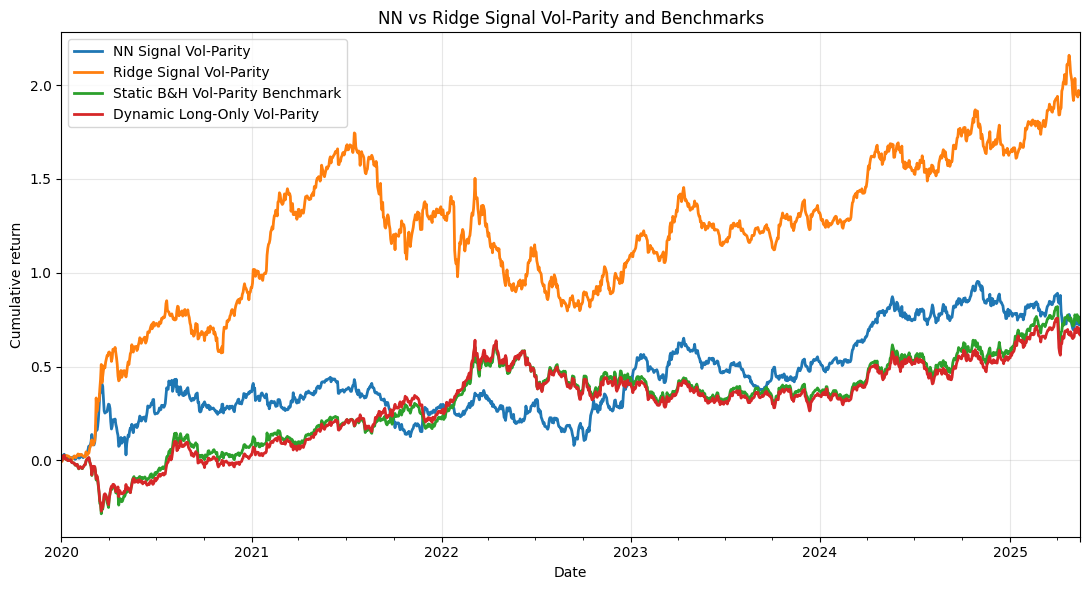

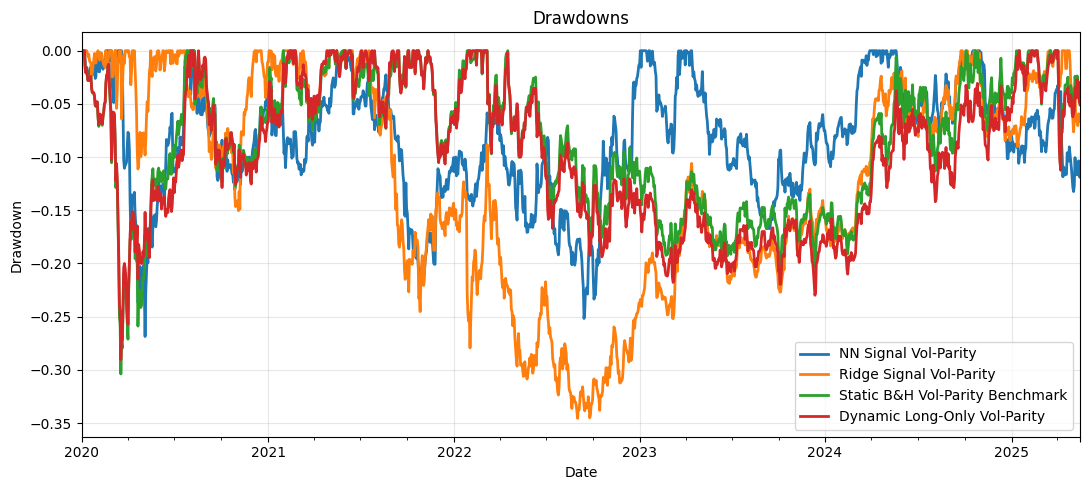


NN signal strategy total return contribution by commodity:
Gold           30.57%
Silver         27.38%
Brent_Crude     7.89%
Natural_Gas    -0.44%
Name: Total Return Contribution, dtype: object

Ridge signal strategy total return contribution by commodity:
Brent_Crude     55.24%
Gold            49.50%
Silver          28.27%
Natural_Gas    -12.65%
Name: Total Return Contribution, dtype: object


In [1]:
"""
Task 3 portfolio backtest for NN and Ridge signal strategies.

Paste this as the next Jupyter notebook code block after both signal-generation blocks:
    1. task3_nn_outputs/nn_test_signals_wide.csv
    2. task3_ridge_outputs/ridge_test_signals_wide.csv or task3_ridge_outputs/nn_test_signals_wide.csv

What this block does
--------------------
1. Loads daily commodity excess returns for Gold, Silver, Brent Crude and Natural Gas.
2. Loads test-window NN and Ridge model signals.
3. Calculates trailing 60-day annualised volatility using only past data.
4. Builds daily inverse-volatility / volatility-parity weights.
5. Constructs these portfolios:
   A. NN signal vol-parity portfolio.
   B. Ridge signal vol-parity portfolio.
   C. Static buy-and-hold vol-parity benchmark.
   D. Dynamic long-only vol-parity benchmark.
6. Saves daily returns, cumulative returns, weights, signals and performance statistics.

Notes
-----
- The model signal files should contain columns: Gold, Silver, Brent_Crude, Natural_Gas.
- The strategy uses signal strength, not just signal sign, through weight = vol-parity weight * signal.
- Transaction costs are zero by default, but can be switched on through TRANSACTION_COST_BPS.
"""

from __future__ import annotations

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =============================================================================
# User-editable settings
# =============================================================================
COMMODITIES_FILE = Path("Commodities Data thru 15May25.xlsx")
OUTPUT_DIR = Path("task3_portfolio_outputs")

# Model signal files. Each model can have a list of fallback paths.
MODEL_SIGNAL_FILES = {
    "NN": [
        Path("task3_nn_outputs/nn_test_signals_wide.csv"),
    ],
    "Ridge": [
        Path("task3_ridge_outputs/ridge_test_signals_wide.csv"),
        Path("task3_ridge_outputs/nn_test_signals_wide.csv"),  # compatibility copy from the Ridge block
    ],
}

DATE_COL_CANDIDATES = ["Date", "Dates"]
TEST_START = pd.Timestamp("2020-01-01")
TRADING_DAYS = 252
VOL_LOOKBACK = 60
VOL_FLOOR = 0.05               # 5% annualised floor prevents extreme weights
MAX_ABS_ASSET_WEIGHT = 0.50    # cap individual exposure after signal scaling
GROSS_EXPOSURE_TARGET = 1.00   # 1.00 = fully invested gross exposure before any vol targeting
PORTFOLIO_VOL_TARGET = None    # Example: 0.12 for 12% annualised portfolio vol target; None = no leverage overlay
PORTFOLIO_VOL_LOOKBACK = 60
TRANSACTION_COST_BPS = 0.0     # bps charged per 100% one-way turnover
EXECUTION_LAG_DAYS = 0         # 0 is OK if model features were already lagged; set 1 for extra conservative execution

SELECTED_COMMODITIES = {
    "Gold": "GOLD 100 OZ",
    "Silver": "SILVER",
    "Brent_Crude": "BRENT CRUDE",
    "Natural_Gas": "NATURAL GAS",
}

# =============================================================================
# Data loading helpers
# =============================================================================
def _normalise_text(x: object) -> str:
    return " ".join(str(x).strip().upper().split())


def _find_existing_path(path: Path) -> Path:
    """Work in notebooks, scripts, or /mnt/data."""
    candidates = [
        Path(path),
        Path.cwd() / path,
        Path.cwd() / path.name,
        Path("/mnt/data") / path,
        Path("/mnt/data") / path.name,
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    raise FileNotFoundError(f"Could not find {path}. Tried: {candidates}")


def _find_first_existing_path(paths) -> Path:
    """Return the first existing path from a list of candidate paths."""
    tried = []
    for path in paths:
        candidates = [
            Path(path),
            Path.cwd() / path,
            Path.cwd() / Path(path).name,
            Path("/mnt/data") / path,
            Path("/mnt/data") / Path(path).name,
        ]
        tried.extend(candidates)
        for candidate in candidates:
            if candidate.exists():
                return candidate
    raise FileNotFoundError(f"Could not find any signal file. Tried: {tried}")


def _match_return_columns_to_assets(return_columns, asset_names) -> dict:
    asset_names = [str(a).strip() for a in asset_names]
    asset_names_sorted = sorted(asset_names, key=lambda s: len(_normalise_text(s)), reverse=True)
    mapping = {}

    for raw_col in return_columns:
        raw_norm = _normalise_text(raw_col)
        match = None
        for asset in asset_names_sorted:
            if raw_norm.startswith(_normalise_text(asset)):
                match = asset
                break
        if match is None:
            raise ValueError(f"Could not match return-index column to Assets sheet: {raw_col}")
        mapping[raw_col] = match

    return mapping


def _read_date_indexed_csv(path: Path) -> pd.DataFrame:
    """Read a CSV whose first column or named date column is the date index."""
    raw = pd.read_csv(path)
    date_col = None
    for candidate in DATE_COL_CANDIDATES:
        if candidate in raw.columns:
            date_col = candidate
            break
    if date_col is None:
        date_col = raw.columns[0]

    raw[date_col] = pd.to_datetime(raw[date_col], errors="coerce")
    raw = raw.dropna(subset=[date_col])
    raw = raw.set_index(date_col).sort_index()
    raw.index.name = "Date"
    raw = raw.apply(pd.to_numeric, errors="coerce")
    return raw.replace([np.inf, -np.inf], np.nan)


def load_commodity_returns() -> pd.DataFrame:
    """
    Prefer the Task 0 CSV output if available. Otherwise read the Excel workbook.
    Returns are daily simple returns calculated from excess return indices.
    """
    csv_candidates = [
        Path("task0_outputs/commodity_daily_returns.csv"),
        Path("commodity_daily_returns.csv"),
        Path("/mnt/data/task0_outputs/commodity_daily_returns.csv"),
        Path("/mnt/data/commodity_daily_returns.csv"),
    ]
    for csv_path in csv_candidates:
        if csv_path.exists():
            return _read_date_indexed_csv(csv_path)

    workbook_path = _find_existing_path(COMMODITIES_FILE)
    raw_indices = pd.read_excel(workbook_path, sheet_name="Return Indices")
    assets = pd.read_excel(workbook_path, sheet_name="Assets")

    date_col = "Dates" if "Dates" in raw_indices.columns else raw_indices.columns[0]
    raw_indices[date_col] = pd.to_datetime(raw_indices[date_col], errors="coerce")
    raw_indices = raw_indices.dropna(subset=[date_col]).sort_values(date_col)
    raw_indices = raw_indices.drop_duplicates(subset=[date_col], keep="last")
    raw_indices = raw_indices.set_index(date_col)
    raw_indices = raw_indices.apply(pd.to_numeric, errors="coerce")

    assets["Commodity"] = assets["Commodity"].astype(str).str.strip()
    col_map = _match_return_columns_to_assets(raw_indices.columns, assets["Commodity"])
    levels = raw_indices.rename(columns=col_map)
    levels = levels[assets["Commodity"].tolist()]

    returns = levels.pct_change(fill_method=None).replace([np.inf, -np.inf], np.nan)
    returns.index.name = "Date"
    return returns


def load_model_signals(model_signal_files: dict[str, list[Path]]) -> dict[str, pd.DataFrame]:
    """Load all model signal files and standardise dates/columns."""
    signals_by_model = {}
    required_cols = list(SELECTED_COMMODITIES.keys())

    for model_name, paths in model_signal_files.items():
        signal_path = _find_first_existing_path(paths)
        signals = _read_date_indexed_csv(signal_path)
        missing_cols = [c for c in required_cols if c not in signals.columns]
        if missing_cols:
            raise ValueError(
                f"{model_name} signal file is missing columns {missing_cols}. "
                f"Found columns: {signals.columns.tolist()}"
            )
        signals = signals[required_cols].clip(-1.0, 1.0)
        signals_by_model[model_name] = signals
        print(f"Loaded {model_name} signals from: {signal_path}")

    return signals_by_model

# =============================================================================
# Portfolio construction helpers
# =============================================================================
def calc_trailing_ann_vol(returns: pd.DataFrame, lookback: int = VOL_LOOKBACK) -> pd.DataFrame:
    """Annualised trailing volatility, shifted so today's return is not used for today's weight."""
    vol = returns.rolling(lookback, min_periods=lookback // 2).std() * np.sqrt(TRADING_DAYS)
    return vol.shift(1).clip(lower=VOL_FLOOR)


def inverse_vol_weights(vol: pd.DataFrame) -> pd.DataFrame:
    """Long-only vol-parity weights. Each row sums to 1 when enough vol data exists."""
    inv_vol = 1.0 / vol
    weights = inv_vol.div(inv_vol.sum(axis=1), axis=0)
    return weights.replace([np.inf, -np.inf], np.nan)


def cap_and_rescale_gross(weights: pd.DataFrame, max_abs_weight: float, gross_target: float) -> pd.DataFrame:
    """
    Cap absolute asset weights, then rescale so gross exposure equals gross_target.
    Keeps sign information from the model signal.
    """
    capped = weights.clip(lower=-max_abs_weight, upper=max_abs_weight)
    gross = capped.abs().sum(axis=1)
    scaled = capped.div(gross.replace(0.0, np.nan), axis=0) * gross_target
    return scaled.fillna(0.0)


def apply_portfolio_vol_target(
    base_weights: pd.DataFrame,
    strategy_returns_pre_target: pd.Series,
    target_vol: float | None = PORTFOLIO_VOL_TARGET,
    lookback: int = PORTFOLIO_VOL_LOOKBACK,
) -> pd.DataFrame:
    """Optional portfolio-level volatility targeting."""
    if target_vol is None:
        return base_weights

    realised_vol = strategy_returns_pre_target.rolling(lookback, min_periods=lookback // 2).std() * np.sqrt(TRADING_DAYS)
    leverage = (target_vol / realised_vol.shift(1)).clip(lower=0.0, upper=3.0)
    return base_weights.mul(leverage, axis=0).fillna(0.0)


def calc_turnover(weights: pd.DataFrame) -> pd.Series:
    """One-way turnover, defined as sum(abs(delta weights))."""
    return weights.diff().abs().sum(axis=1).fillna(weights.abs().sum(axis=1))


def calc_portfolio_returns(weights: pd.DataFrame, returns: pd.DataFrame, tc_bps: float = TRANSACTION_COST_BPS) -> tuple[pd.Series, pd.Series]:
    """Daily portfolio return = sum_i weight_i,t * return_i,t minus optional turnover costs."""
    aligned_weights, aligned_returns = weights.align(returns, join="inner", axis=0)
    gross_returns = (aligned_weights * aligned_returns).sum(axis=1)
    turnover = calc_turnover(aligned_weights)
    costs = turnover * (tc_bps / 10000.0)
    net_returns = gross_returns - costs
    return net_returns.rename("Return"), turnover.rename("Turnover")


def performance_stats(r: pd.Series, turnover: pd.Series | None = None) -> pd.Series:
    r = r.dropna()
    if len(r) == 0:
        return pd.Series(dtype=float)

    cumulative = (1.0 + r).cumprod()
    drawdown = cumulative / cumulative.cummax() - 1.0

    ann_return = cumulative.iloc[-1] ** (TRADING_DAYS / len(r)) - 1.0
    ann_vol = r.std() * np.sqrt(TRADING_DAYS)
    sharpe = ann_return / ann_vol if ann_vol and ann_vol > 0 else np.nan
    max_dd = drawdown.min()
    calmar = ann_return / abs(max_dd) if max_dd < 0 else np.nan
    hit_rate = (r > 0).mean()

    out = pd.Series({
        "Ann Return": ann_return,
        "Ann Vol": ann_vol,
        "Sharpe": sharpe,
        "Max Drawdown": max_dd,
        "Calmar": calmar,
        "Total Return": cumulative.iloc[-1] - 1.0,
        "Hit Rate": hit_rate,
        "Skew": r.skew(),
        "Avg Daily Return": r.mean(),
        "Worst Day": r.min(),
        "Best Day": r.max(),
    })

    if turnover is not None:
        turnover = turnover.reindex(r.index).dropna()
        out["Avg Daily Turnover"] = turnover.mean()
        out["Annualised Turnover"] = turnover.mean() * TRADING_DAYS

    return out


def build_signal_strategy(
    model_name: str,
    signals: pd.DataFrame,
    base_vp_weights: pd.DataFrame,
    returns_4: pd.DataFrame,
    common_index: pd.Index,
) -> tuple[pd.Series, pd.Series, pd.DataFrame, pd.DataFrame]:
    """Build one signal-driven vol-parity strategy for a model."""
    model_signals = signals.reindex(common_index).shift(EXECUTION_LAG_DAYS)
    raw_signal_weights = base_vp_weights * model_signals
    weights_pre_target = cap_and_rescale_gross(
        raw_signal_weights,
        max_abs_weight=MAX_ABS_ASSET_WEIGHT,
        gross_target=GROSS_EXPOSURE_TARGET,
    )

    returns_pre_target, _ = calc_portfolio_returns(weights_pre_target, returns_4, tc_bps=0.0)
    weights = apply_portfolio_vol_target(weights_pre_target, returns_pre_target)
    strategy_returns, strategy_turnover = calc_portfolio_returns(weights, returns_4, tc_bps=TRANSACTION_COST_BPS)

    strategy_returns.name = f"{model_name} Signal Vol-Parity"
    strategy_turnover.name = f"{model_name} Signal Vol-Parity"
    return strategy_returns, strategy_turnover, weights, model_signals

# =============================================================================
# Run portfolio backtest
# =============================================================================
returns_all = load_commodity_returns()
signals_by_model = load_model_signals(MODEL_SIGNAL_FILES)

# Map clean signal labels to the commodity names in the returns DataFrame.
asset_name_map = {label: commodity for label, commodity in SELECTED_COMMODITIES.items()}
required_return_cols = [asset_name_map[label] for label in SELECTED_COMMODITIES.keys()]
missing_return_cols = [c for c in required_return_cols if c not in returns_all.columns]
if missing_return_cols:
    raise ValueError(f"Missing return columns: {missing_return_cols}")

returns_4 = returns_all[required_return_cols].copy()
returns_4.columns = list(SELECTED_COMMODITIES.keys())
returns_4 = returns_4.loc[returns_4.index >= TEST_START]

# Use the intersection of return dates and all model signal dates for a fair comparison.
common_index = returns_4.index
for model_signals in signals_by_model.values():
    common_index = common_index.intersection(model_signals.loc[model_signals.index >= TEST_START].index)
common_index = common_index.sort_values()

returns_4 = returns_4.loc[common_index]
if len(returns_4) == 0:
    raise ValueError("No overlapping dates between commodity returns and model signal files.")

# Vol-parity base weights from trailing realised vol.
trailing_vol = calc_trailing_ann_vol(returns_all[required_return_cols])
trailing_vol.columns = list(SELECTED_COMMODITIES.keys())
trailing_vol = trailing_vol.reindex(common_index)
base_vp_weights = inverse_vol_weights(trailing_vol).fillna(0.0)

# A and B. Signal strategies for each model.
model_returns = []
model_turnovers = []
model_weights = {}
model_signals_aligned = {}

for model_name, signals in signals_by_model.items():
    strategy_returns, strategy_turnover, weights, tradable_signals = build_signal_strategy(
        model_name=model_name,
        signals=signals,
        base_vp_weights=base_vp_weights,
        returns_4=returns_4,
        common_index=common_index,
    )
    model_returns.append(strategy_returns)
    model_turnovers.append(strategy_turnover)
    model_weights[f"{model_name}_Signal_Weights"] = weights
    model_signals_aligned[f"{model_name}_Signals"] = tradable_signals

# C. Static buy-and-hold benchmark: use the first available vol-parity weights and hold them fixed.
valid_weight_mask = base_vp_weights.abs().sum(axis=1) > 0
if not valid_weight_mask.any():
    raise ValueError("No valid vol-parity weights were available. Check return data and vol lookback.")

first_valid_weight_date = base_vp_weights.index[valid_weight_mask][0]
initial_vp_weights = base_vp_weights.loc[first_valid_weight_date]
static_bh_weights = pd.DataFrame(
    np.tile(initial_vp_weights.values, (len(base_vp_weights), 1)),
    index=base_vp_weights.index,
    columns=base_vp_weights.columns,
)
static_bh_weights = cap_and_rescale_gross(
    static_bh_weights,
    max_abs_weight=MAX_ABS_ASSET_WEIGHT,
    gross_target=GROSS_EXPOSURE_TARGET,
)
static_bh_returns, static_bh_turnover = calc_portfolio_returns(static_bh_weights, returns_4, tc_bps=TRANSACTION_COST_BPS)
static_bh_returns.name = "Static B&H Vol-Parity Benchmark"
static_bh_turnover.name = "Static B&H Vol-Parity Benchmark"

# D. Dynamic long-only benchmark: same daily vol-parity risk weights, always long.
dyn_bh_weights_pre_target = cap_and_rescale_gross(
    base_vp_weights,
    max_abs_weight=MAX_ABS_ASSET_WEIGHT,
    gross_target=GROSS_EXPOSURE_TARGET,
)
dyn_bh_returns_pre_target, _ = calc_portfolio_returns(dyn_bh_weights_pre_target, returns_4, tc_bps=0.0)
dyn_bh_weights = apply_portfolio_vol_target(dyn_bh_weights_pre_target, dyn_bh_returns_pre_target)
dyn_bh_returns, dyn_bh_turnover = calc_portfolio_returns(dyn_bh_weights, returns_4, tc_bps=TRANSACTION_COST_BPS)
dyn_bh_returns.name = "Dynamic Long-Only Vol-Parity"
dyn_bh_turnover.name = "Dynamic Long-Only Vol-Parity"

# Combine outputs.
portfolio_returns = pd.concat(
    model_returns + [static_bh_returns, dyn_bh_returns],
    axis=1,
).dropna()

turnover = pd.concat(
    model_turnovers + [static_bh_turnover, dyn_bh_turnover],
    axis=1,
).reindex(portfolio_returns.index)

cumulative_returns = (1.0 + portfolio_returns).cumprod() - 1.0
weights_out = pd.concat(
    {
        **{k: v.reindex(portfolio_returns.index) for k, v in model_weights.items()},
        "Static_Buy_Hold_Vol_Parity_Weights": static_bh_weights.reindex(portfolio_returns.index),
        "Dynamic_Long_Only_Vol_Parity_Weights": dyn_bh_weights.reindex(portfolio_returns.index),
        **{k: v.reindex(portfolio_returns.index) for k, v in model_signals_aligned.items()},
        "Trailing_Ann_Vol": trailing_vol.reindex(portfolio_returns.index),
    },
    axis=1,
)

stats = pd.DataFrame({
    col: performance_stats(portfolio_returns[col], turnover[col])
    for col in portfolio_returns.columns
}).T

# Relative comparisons against the static buy-and-hold benchmark.
relative_stats_rows = []
for col in portfolio_returns.columns:
    if "Signal Vol-Parity" in col:
        relative_return = portfolio_returns[col] - portfolio_returns["Static B&H Vol-Parity Benchmark"]
        relative_stats_rows.append(
            performance_stats(relative_return).rename(f"{col} minus Static B&H")
        )
if relative_stats_rows:
    stats = pd.concat([stats, pd.DataFrame(relative_stats_rows)], axis=0)

print("\nTask 3 portfolio comparison, test window")
print(f"Date range: {portfolio_returns.index.min().date()} to {portfolio_returns.index.max().date()}")
print(f"Transaction cost assumption: {TRANSACTION_COST_BPS:.2f} bps per 100% one-way turnover")
print("\nPerformance statistics:")
display_cols = ["Ann Return", "Ann Vol", "Sharpe", "Max Drawdown", "Calmar", "Total Return", "Hit Rate", "Avg Daily Turnover"]
stats_display = stats[display_cols].copy()
stats_display = stats_display.map(lambda x: f"{x:,.2%}" if pd.notna(x) and abs(x) < 10 else f"{x:,.2f}")
print(stats_display)

# Save CSV outputs for report charts/tables.
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
portfolio_returns.to_csv(OUTPUT_DIR / "portfolio_returns_test.csv", index_label="Date")
cumulative_returns.to_csv(OUTPUT_DIR / "portfolio_cumulative_returns_test.csv", index_label="Date")
weights_out.to_csv(OUTPUT_DIR / "portfolio_weights_signals_and_vols_test.csv", index_label="Date")
stats.to_csv(OUTPUT_DIR / "portfolio_performance_stats_test.csv", index_label="Strategy")

# Plot cumulative performance.
ax = cumulative_returns.plot(figsize=(11, 6), linewidth=2)
ax.set_title("NN vs Ridge Signal Vol-Parity and Benchmarks")
ax.set_ylabel("Cumulative return")
ax.set_xlabel("Date")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "portfolio_cumulative_returns_test.png", dpi=150)
plt.show()

# Plot drawdowns.
growth = (1.0 + portfolio_returns).cumprod()
drawdowns = growth / growth.cummax() - 1.0
ax = drawdowns.plot(figsize=(11, 5), linewidth=2)
ax.set_title("Drawdowns")
ax.set_ylabel("Drawdown")
ax.set_xlabel("Date")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "portfolio_drawdowns_test.png", dpi=150)
plt.show()

# Contribution tables by commodity for each model strategy.
for model_name, weights in model_weights.items():
    strategy_name = model_name.replace("_Signal_Weights", "")
    asset_contrib = (weights.reindex(portfolio_returns.index) * returns_4.reindex(portfolio_returns.index)).sum(axis=0)
    asset_contrib = asset_contrib.sort_values(ascending=False).rename("Total Return Contribution")
    print(f"\n{strategy_name} signal strategy total return contribution by commodity:")
    print(asset_contrib.apply(lambda x: f"{x:,.2%}"))


For each commodity, we trained a separate small feed-forward neural network to predict the next 21-trading-day excess return scaled by trailing 60-day annualised volatility. The input features combined commodity-specific trend and volatility variables with economically motivated auxiliary variables, including FX, rates, credit spreads, equity indices, implied volatility, macro surprise indices and positioning. All features were lagged by one trading day to avoid using information unavailable at the time of signal formation. The model was trained on the pre-2020 sample, with 2019 used for validation and 2020 onward reserved for out-of-sample testing. The network had two hidden layers with 32 and 16 units, ReLU activations, dropout and weight decay to reduce overfitting. The final prediction was transformed through a tanh function to produce a bounded signal between -1 and +1, which was then used in the portfolio construction step.

Comparison return sample:


,NN Signal Vol-Parity,Ridge Signal Vol-Parity,Static B&H Vol-Parity Benchmark,Dynamic Long-Only Vol-Parity,Full_23_Commodity_Market_Factor,Four_Asset_Equal_Weight_Factor
Date,,,,,,
2020-01-01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2020-01-02,0.004622,-0.005982,0.001318,0.001316,0.000501,-0.004194
2020-01-03,0.016485,0.009874,0.016347,0.016338,0.000257,0.015301
2020-01-06,0.007213,0.004554,0.006169,0.006135,0.000761,0.004692
2020-01-07,0.004047,0.002748,0.003778,0.003824,0.000460,0.004641


Date range:
2020-01-01 00:00:00 to 2025-05-15 00:00:00
Number of observations: 1402


,Ann Return,Ann Vol,Sharpe,Max Drawdown,Calmar,Skew,Total Return,Obs
Strategy,,,,,,,,
NN Signal Vol-Parity,0.102593,0.199319,0.514717,-0.268652,0.381880,-0.113814,0.721777,1402
Ridge Signal Vol-Parity,0.214990,0.207981,1.033696,-0.345580,0.622112,0.572309,1.954736,1402
Static B&H Vol-Parity Benchmark,0.103947,0.200674,0.517989,-0.303880,0.342065,-0.457619,0.733570,1402
Dynamic Long-Only Vol-Parity,0.096445,0.192740,0.500389,-0.290347,0.332172,-0.399348,0.669040,1402
Full_23_Commodity_Market_Factor,0.065973,0.166702,0.395756,-0.423572,0.155755,-2.538671,0.426811,1402
Four_Asset_Equal_Weight_Factor,0.077551,0.254404,0.304833,-0.397110,0.195288,-0.128322,0.515190,1402


,NN Signal Vol-Parity,Ridge Signal Vol-Parity,Static B&H Vol-Parity Benchmark,Dynamic Long-Only Vol-Parity,Full_23_Commodity_Market_Factor,Four_Asset_Equal_Weight_Factor
Date,,,,,,
2025-05-09,1.748552,2.945611,1.776616,1.710688,1.418666,1.564577
2025-05-12,1.726689,2.936277,1.745364,1.684489,1.416188,1.538631
2025-05-13,1.751790,2.971443,1.766201,1.705995,1.435848,1.556597
2025-05-14,1.722868,2.948392,1.733167,1.673194,1.429533,1.522063
2025-05-15,1.721777,2.954736,1.733570,1.669040,1.426811,1.515190


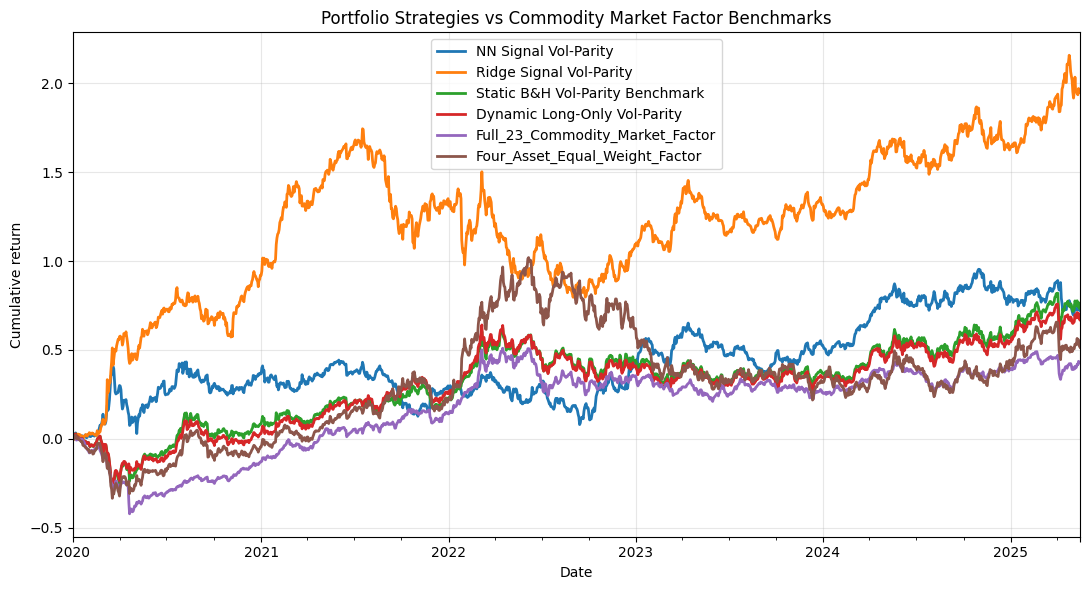

Annualised Alpha  \
Strategy                        Benchmark                                           
NN Signal Vol-Parity            Full 23-Commodity Market Factor          0.116969   
                                Four-Asset Equal-Weight Factor           0.128582   
Ridge Signal Vol-Parity         Full 23-Commodity Market Factor          0.202150   
                                Four-Asset Equal-Weight Factor           0.216902   
Static B&H Vol-Parity Benchmark Full 23-Commodity Market Factor          0.049817   
                                Four-Asset Equal-Weight Factor           0.043945   
Dynamic Long-Only Vol-Parity    Full 23-Commodity Market Factor          0.046449   
                                Four-Asset Equal-Weight Factor           0.037629   

                                                                 Market Beta  \
Strategy                        Benchmark                                      
NN Signal Vol-Parity            Full 23-Commodity Market Factor     0.007470   
                                Four-Asset Equal-Weight Factor     -0.102996   
Ridge Signal Vol-Parity         Full 23-Commodity Market Factor     0.181639   
                                Four-Asset Equal-Weight Factor     -0.005380   
Static B&H Vol-Parity Benchmark Full 23-Commodity Market Factor     0.887828   
                                Four-Asset Equal-Weight Factor      0.701870   
Dynamic Long-Only Vol-Parity    Full 23-Commodity Market Factor     0.823357   
                                Four-Asset Equal-Weight Factor      0.682412   

                                                                 R_squared  \
Strategy                        Benchmark                                    
NN Signal Vol-Parity            Full 23-Commodity Market Factor   0.000039   
                                Four-Asset Equal-Weight Factor    0.017282   
Ridge Signal Vol-Parity         Full 23-Commodity Market Factor   0.021196   
                                Four-Asset Equal-Weight Factor    0.000043   
Static B&H Vol-Parity Benchmark Full 23-Commodity Market Factor   0.543951   
                                Four-Asset Equal-Weight Factor    0.791734   
Dynamic Long-Only Vol-Parity    Full 23-Commodity Market Factor   0.507124   
                                Four-Asset Equal-Weight Factor    0.811327   

                                                                 Alpha t-stat  \
Strategy                        Benchmark                                       
NN Signal Vol-Parity            Full 23-Commodity Market Factor      1.383114   
                                Four-Asset Equal-Weight Factor       1.533845   
Ridge Signal Vol-Parity         Full 23-Commodity Market Factor      2.315421   
                                Four-Asset Equal-Weight Factor       2.458187   
Static B&H Vol-Parity Benchmark Full 23-Commodity Market Factor      0.866385   
                                Four-Asset Equal-Weight Factor       1.131029   
Dynamic Long-Only Vol-Parity    Full 23-Commodity Market Factor      0.809031   
                                Four-Asset Equal-Weight Factor       1.059396   

                                                                 Beta t-stat  \
Strategy                        Benchmark                                      
NN Signal Vol-Parity            Full 23-Commodity Market Factor     0.233775   
                                Four-Asset Equal-Weight Factor     -4.961872   
Ridge Signal Vol-Parity         Full 23-Commodity Market Factor     5.506071   
                                Four-Asset Equal-Weight Factor     -0.246249   
Static B&H Vol-Parity Benchmark Full 23-Commodity Market Factor    40.863704   
                                Four-Asset Equal-Weight Factor     72.953296   
Dynamic Long-Only Vol-Parity    Full 23-Commodity Market Factor    37.953557   
                                Four-Asset Equal-Weight Factor     77.590206   

                    

Saved outputs to: /Users/jwu/Downloads/Backtesting Project/task3_market_factor_comparison_outputs


In [2]:
# =============================================================================
# Task 3 Market Factor Benchmark Comparison
# Includes NN, Ridge, static buy-and-hold and dynamic long-only portfolios
# Active-return table output removed
# =============================================================================

import pandas as pd
import numpy as np
import statsmodels.api as sm
from pathlib import Path
import matplotlib.pyplot as plt

TRADING_DAYS = 252

# -----------------------------
# Directory paths
# -----------------------------
task0_dir = Path("task0_outputs")
portfolio_dir = Path("task3_portfolio_outputs")
output_dir = Path("task3_market_factor_comparison_outputs")
output_dir.mkdir(exist_ok=True)

# -----------------------------
# File paths
# -----------------------------
portfolio_returns_path = portfolio_dir / "portfolio_returns_test.csv"
commodity_returns_path = task0_dir / "commodity_daily_returns.csv"
market_factor_path = task0_dir / "commodity_market_factor.csv"

# Fallbacks for notebook folders where CSVs are in the current working directory.
def find_path(primary_path: Path, fallback_name: str) -> Path:
    candidates = [
        primary_path,
        Path(fallback_name),
        Path.cwd() / fallback_name,
        Path("/mnt/data") / fallback_name,
        Path("/mnt/data") / primary_path,
    ]
    for p in candidates:
        if p.exists():
            return p
    raise FileNotFoundError(f"Could not find {fallback_name}. Tried: {candidates}")

portfolio_returns_path = find_path(portfolio_returns_path, "portfolio_returns_test.csv")
commodity_returns_path = find_path(commodity_returns_path, "commodity_daily_returns.csv")
market_factor_path = find_path(market_factor_path, "commodity_market_factor.csv")

# -----------------------------
# Load data
# -----------------------------
strategy_returns = pd.read_csv(
    portfolio_returns_path,
    index_col=0,
    parse_dates=True,
)

commodity_returns = pd.read_csv(
    commodity_returns_path,
    index_col=0,
    parse_dates=True,
)

market_factor = pd.read_csv(
    market_factor_path,
    index_col=0,
    parse_dates=True,
)

# Clean indices and column names.
for df in [strategy_returns, commodity_returns, market_factor]:
    df.index = pd.to_datetime(df.index)
    df.sort_index(inplace=True)
    df.columns = df.columns.astype(str).str.strip()

# -----------------------------
# Build market factor benchmarks
# -----------------------------
full_market = market_factor["MKT_EQ_WEIGHT_AVAILABLE"].rename(
    "Full_23_Commodity_Market_Factor"
)

four_asset_cols = [
    "GOLD 100 OZ",
    "SILVER",
    "BRENT CRUDE",
    "NATURAL GAS",
]

missing_cols = [c for c in four_asset_cols if c not in commodity_returns.columns]
if missing_cols:
    raise ValueError(f"Missing four-asset columns in commodity_returns: {missing_cols}")

four_asset_factor = (
    commodity_returns[four_asset_cols]
    .mean(axis=1, skipna=True)
    .rename("Four_Asset_Equal_Weight_Factor")
)

# -----------------------------
# Align all benchmark returns to the portfolio return dates
# -----------------------------
comparison_returns = pd.concat(
    [
        strategy_returns,
        full_market.reindex(strategy_returns.index),
        four_asset_factor.reindex(strategy_returns.index),
    ],
    axis=1,
).dropna()

if comparison_returns.empty:
    raise ValueError(
        "comparison_returns is empty after alignment. Check date overlap and column names."
    )

print("Comparison return sample:")
display(comparison_returns.head())

print("Date range:")
print(comparison_returns.index.min(), "to", comparison_returns.index.max())
print("Number of observations:", len(comparison_returns))

# -----------------------------
# Performance statistics
# -----------------------------
def performance_stats(returns, trading_days=252):
    stats = []

    for col in returns.columns:
        r = pd.to_numeric(returns[col], errors="coerce").dropna()

        if len(r) == 0:
            print(f"Skipping {col}: no valid observations")
            continue

        cumulative = (1.0 + r).cumprod()
        drawdown = cumulative / cumulative.cummax() - 1.0

        ann_return = cumulative.iloc[-1] ** (trading_days / len(r)) - 1.0
        ann_vol = r.std() * np.sqrt(trading_days)
        sharpe = ann_return / ann_vol if ann_vol != 0 else np.nan
        max_dd = drawdown.min()
        calmar = ann_return / abs(max_dd) if max_dd != 0 else np.nan
        total_return = cumulative.iloc[-1] - 1.0

        stats.append({
            "Strategy": col,
            "Ann Return": ann_return,
            "Ann Vol": ann_vol,
            "Sharpe": sharpe,
            "Max Drawdown": max_dd,
            "Calmar": calmar,
            "Skew": r.skew(),
            "Total Return": total_return,
            "Obs": len(r),
        })

    if len(stats) == 0:
        raise ValueError("No valid return series were available for performance_stats().")

    return pd.DataFrame(stats).set_index("Strategy")

stats_table = performance_stats(comparison_returns)
display(stats_table)

# -----------------------------
# Cumulative performance
# -----------------------------
cumulative_returns = (1.0 + comparison_returns).cumprod()
display(cumulative_returns.tail())

ax = (cumulative_returns - 1.0).plot(figsize=(11, 6), linewidth=2)
ax.set_title("Portfolio Strategies vs Commodity Market Factor Benchmarks")
ax.set_ylabel("Cumulative return")
ax.set_xlabel("Date")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(output_dir / "strategy_vs_market_factor_cumulative_returns.png", dpi=150)
plt.show()

# -----------------------------
# Market factor regression
# -----------------------------
def market_factor_regression(strategy_ret, market_ret, trading_days=252):
    df = pd.concat([strategy_ret, market_ret], axis=1).dropna()
    df.columns = ["strategy", "market"]

    if len(df) < 30:
        return {
            "Annualised Alpha": np.nan,
            "Market Beta": np.nan,
            "R_squared": np.nan,
            "Alpha t-stat": np.nan,
            "Beta t-stat": np.nan,
            "Obs": len(df),
        }

    X = sm.add_constant(df["market"])
    y = df["strategy"]
    model = sm.OLS(y, X).fit()

    return {
        "Annualised Alpha": model.params["const"] * trading_days,
        "Market Beta": model.params["market"],
        "R_squared": model.rsquared,
        "Alpha t-stat": model.tvalues["const"],
        "Beta t-stat": model.tvalues["market"],
        "Obs": len(df),
    }

regression_rows = []
strategy_cols = list(strategy_returns.columns)

for strategy_col in strategy_cols:
    reg_full = market_factor_regression(
        comparison_returns[strategy_col],
        comparison_returns["Full_23_Commodity_Market_Factor"],
    )
    reg_full["Strategy"] = strategy_col
    reg_full["Benchmark"] = "Full 23-Commodity Market Factor"
    regression_rows.append(reg_full)

    reg_four = market_factor_regression(
        comparison_returns[strategy_col],
        comparison_returns["Four_Asset_Equal_Weight_Factor"],
    )
    reg_four["Strategy"] = strategy_col
    reg_four["Benchmark"] = "Four-Asset Equal-Weight Factor"
    regression_rows.append(reg_four)

regression_table = pd.DataFrame(regression_rows).set_index(["Strategy", "Benchmark"])
display(regression_table)

# -----------------------------
# Save outputs
# -----------------------------
comparison_returns.to_csv(output_dir / "strategy_vs_market_factor_returns.csv")
cumulative_returns.to_csv(output_dir / "strategy_vs_market_factor_cumulative_returns.csv")
stats_table.to_csv(output_dir / "strategy_vs_market_factor_stats.csv")
regression_table.to_csv(output_dir / "strategy_market_factor_regressions.csv")

print(f"Saved outputs to: {output_dir.resolve()}")
